<a href="https://www.kaggle.com/code/sonawanelalitsunil/shopping-behaviours-dataset-ml-100?scriptVersionId=260776331" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shopping-behaviours-dataset/shopping_behavior_updated.csv


## Title: Shopping Behaviours Dataset

## Description:
The Shopping Behaviours dataset provides detailed insights into customer purchasing patterns, preferences, and decision-making factors. It includes attributes related to demographics, shopping frequency, product categories, spending habits, payment methods, and satisfaction levels. By analyzing this dataset, one can uncover trends in consumer behavior, identify factors influencing purchase decisions, segment customers based on their habits, and predict future buying intentions. It is highly useful for market research, targeted marketing strategies, recommendation systems, and improving overall customer experience in retail and e-commerce.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/shopping-behaviours-dataset/shopping_behavior_updated.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [10]:
df.shape

(3900, 18)

In [11]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

## data visualizations

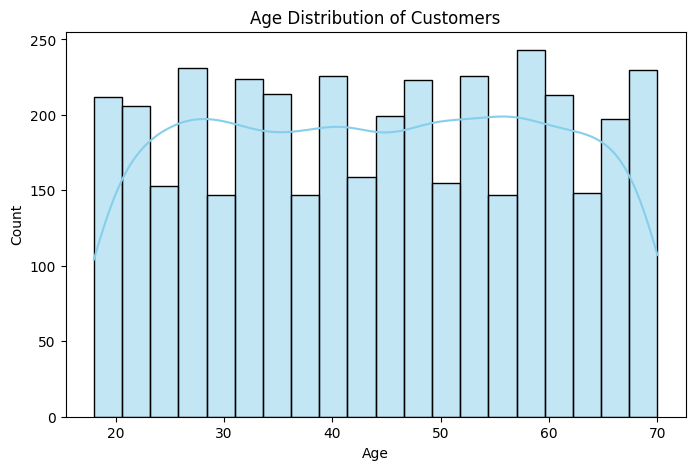

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

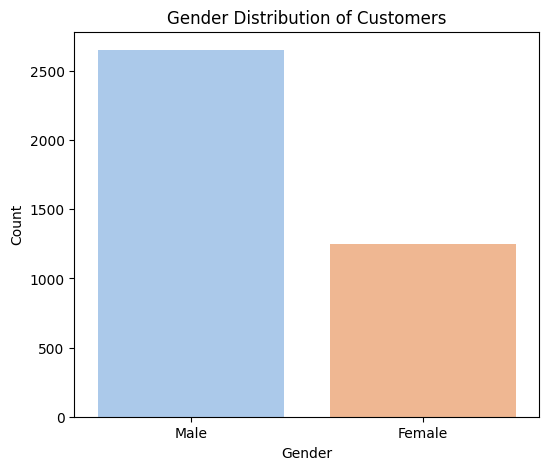

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(x="Gender", data=df, palette="pastel")
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

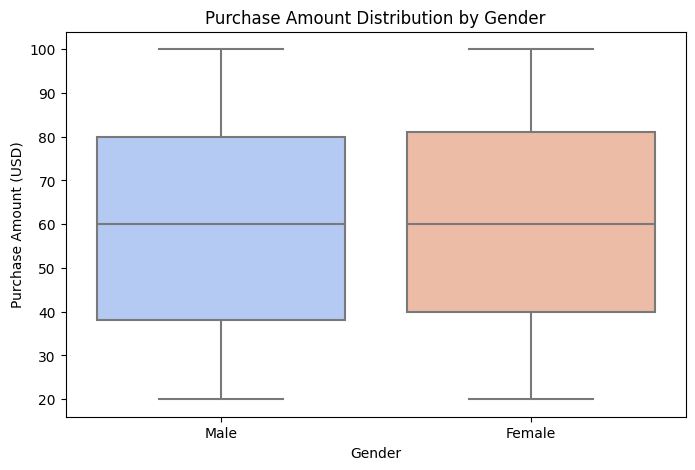

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Gender", y="Purchase Amount (USD)", data=df, palette="coolwarm")
plt.title("Purchase Amount Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount (USD)")
plt.show()


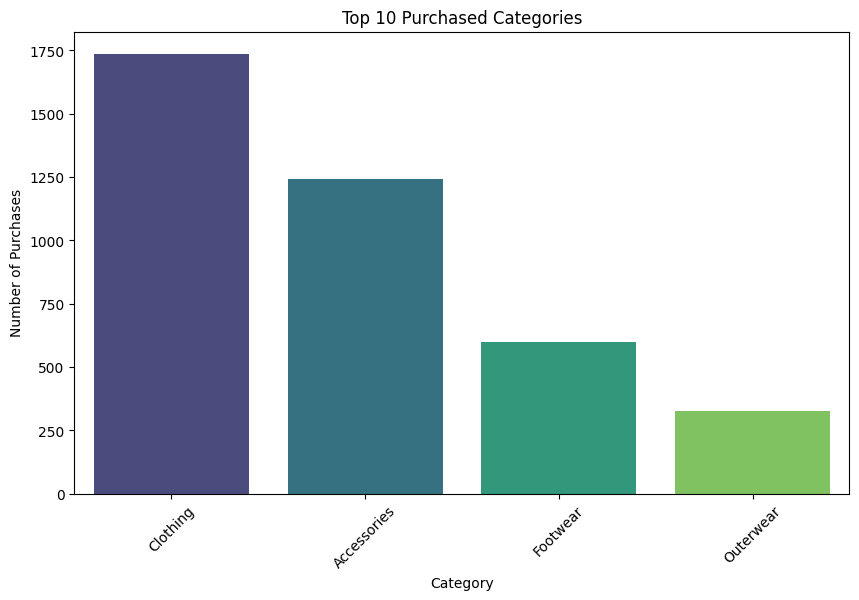

In [15]:
plt.figure(figsize=(10,6))
top_cats = df['Category'].value_counts().head(10)
sns.barplot(x=top_cats.index, y=top_cats.values, palette="viridis")
plt.title("Top 10 Purchased Categories")
plt.xticks(rotation=45)
plt.ylabel("Number of Purchases")
plt.show()

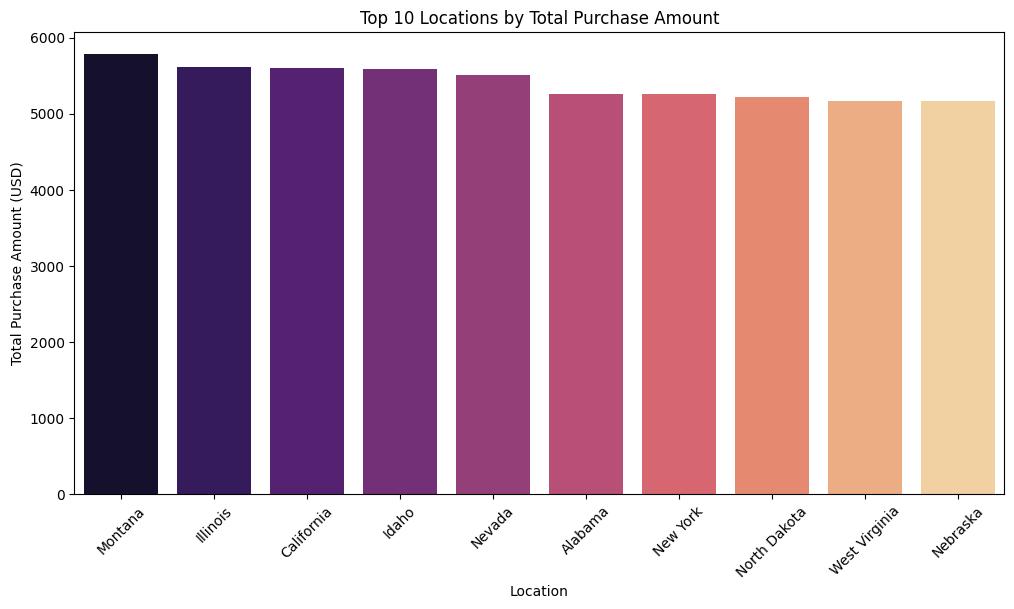

In [16]:
plt.figure(figsize=(12,6))
location_sales = df.groupby("Location")["Purchase Amount (USD)"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=location_sales.index, y=location_sales.values, palette="magma")
plt.title("Top 10 Locations by Total Purchase Amount")
plt.xticks(rotation=45)
plt.ylabel("Total Purchase Amount (USD)")
plt.show()

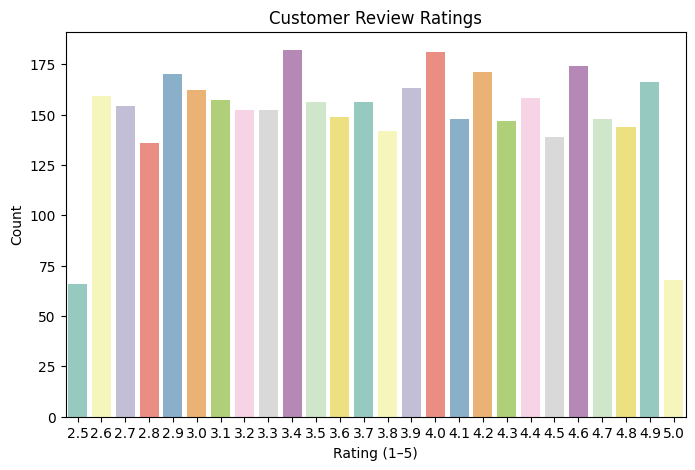

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x="Review Rating", data=df, palette="Set3")
plt.title("Customer Review Ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.show()

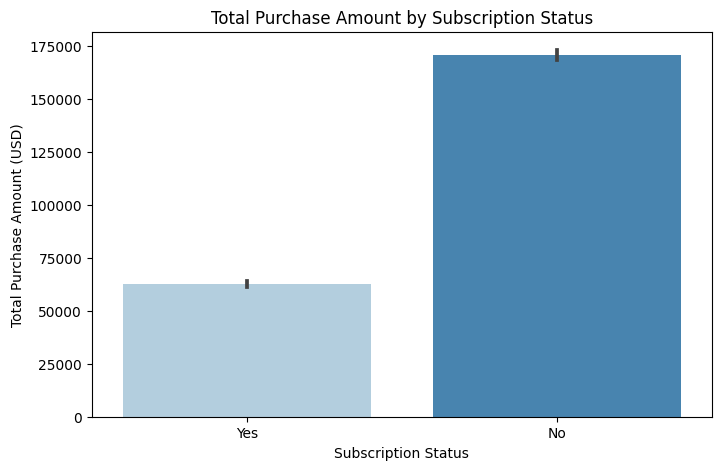

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x="Subscription Status", y="Purchase Amount (USD)", data=df, estimator=sum, palette="Blues")
plt.title("Total Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Total Purchase Amount (USD)")
plt.show()

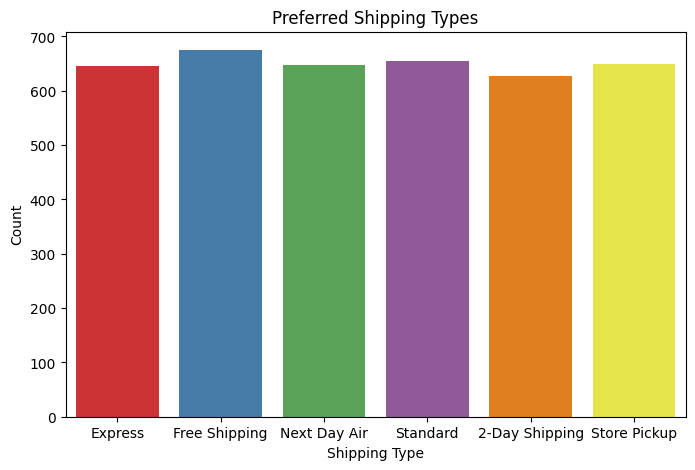

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="Shipping Type", data=df, palette="Set1")
plt.title("Preferred Shipping Types")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.show()

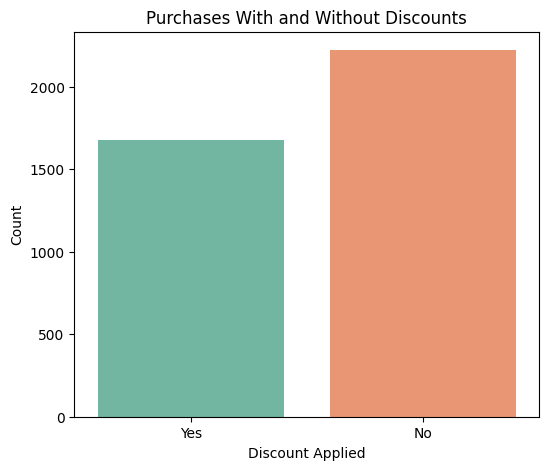

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(x="Discount Applied", data=df, palette="Set2")
plt.title("Purchases With and Without Discounts")
plt.xlabel("Discount Applied")
plt.ylabel("Count")
plt.show()

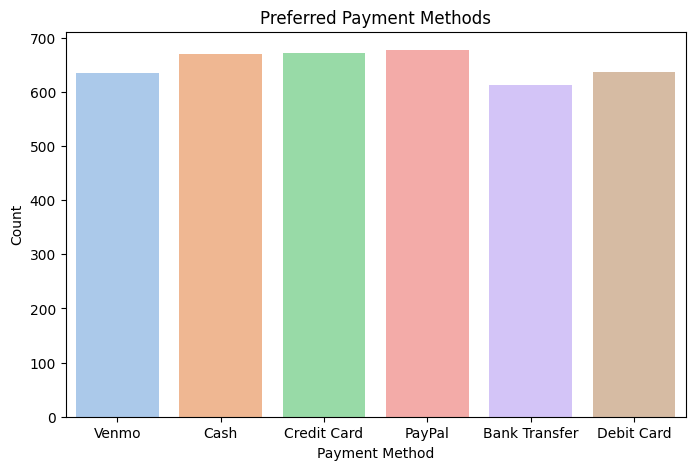

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x="Payment Method", data=df, palette="pastel")
plt.title("Preferred Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

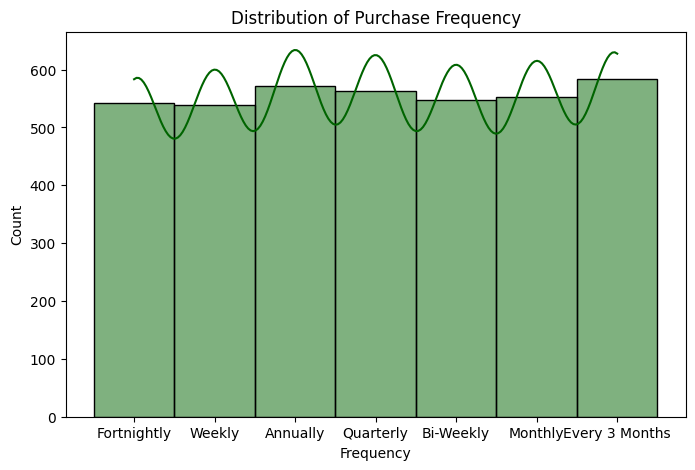

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Frequency of Purchases'], bins=20, kde=True, color="darkgreen")
plt.title("Distribution of Purchase Frequency")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()

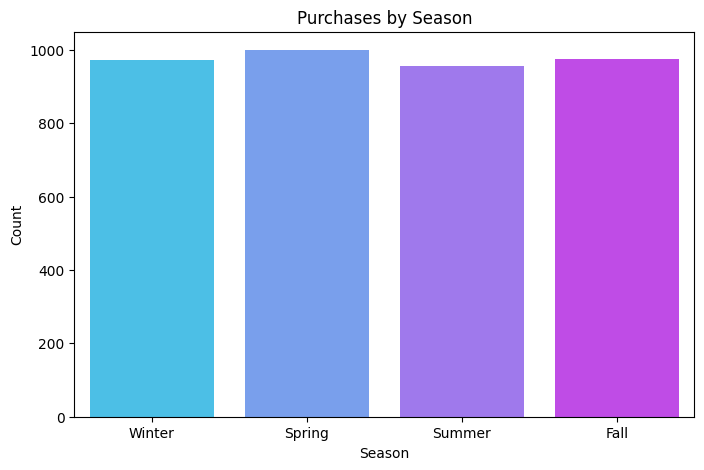

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x="Season", data=df, palette="cool")
plt.title("Purchases by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.show()

## Predictive modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [25]:
df = df.fillna("Unknown")

# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':  # Encode only categorical features
        df[col] = le.fit_transform(df[col])
X = df.drop("Subscription Status", axis=1)   # Features
y = df["Subscription Status"]                # Target (classification)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

In [27]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)            
    y_pred = model.predict(X_test)         
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
print("Model Performance (Accuracy %):")
for model, acc in results.items():
    print(f"{model:25} : {acc:.2f} %")

Model Performance (Accuracy %):
Logistic Regression       : 99.23 %
Decision Tree             : 100.00 %
Random Forest             : 100.00 %
Gradient Boosting         : 100.00 %
K-Nearest Neighbors       : 99.62 %
Support Vector Machine    : 99.74 %


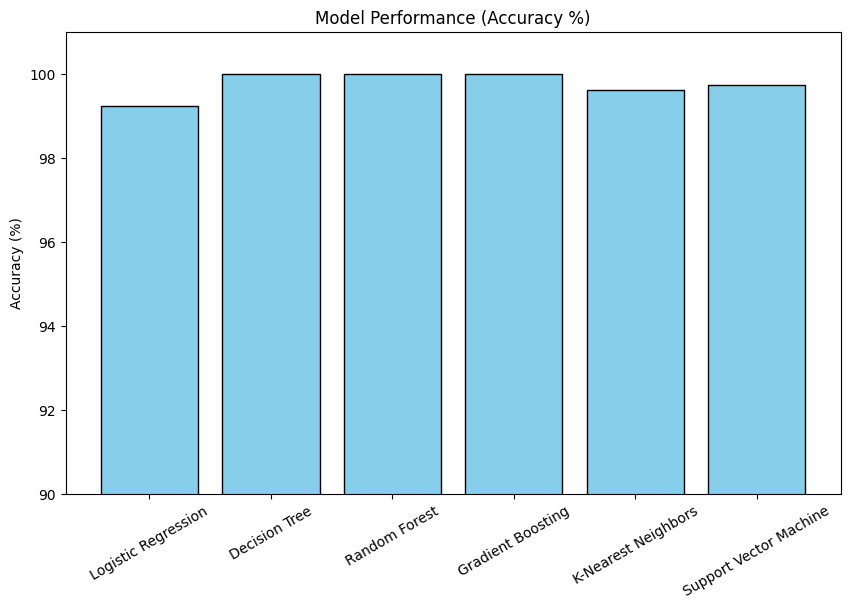

In [28]:
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color="skyblue", edgecolor="black")
plt.title("Model Performance (Accuracy %)")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.ylim(90, 101)  # zoom in since all models are 99–100%
plt.show()

## Thank you..pls upvote!!!!!